Exercise 1- Conceptual Questions

1. Problem Components

a-Mouse in a maze
- Agent: Mouse
- Environment: Maze
- State: Mouse position
- Actions: Move (left, right, forward)
- Reward: +1 for cheese

b-Stock market AI
- Agent: Trading algorithm
- Environment: Market
- State: Prices, indicators
- Actions: Buy, Sell, Hold
- Reward: Profit

c-Thermostat
- Agent: Thermostat system
- Environment: Room
- State: Current temperature
- Actions: Increase/decrease temperature
- Reward: Comfort - energy cost

2. Epsilon Values

If ε = 0
- Always exploit (no exploration)
- Risk: may get stuck in bad solution

If ε = 1
- Always explore (random actions)
- Risk: never learns best action

Both extremes are bad for long-term learning

3. Reward Shaping

Giving intermediate rewards helps the agent learn faster.

- The agent receives more feedback
- It understands which steps lead to success

This speeds up learning compared to only final reward

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class Bandit:
    def __init__(self, k=10):
        self.k = k
        self.win_rates = np.random.rand(k)
    
    def pull(self, arm):
        if np.random.rand() < self.win_rates[arm]:
            return 1
        return 0

In [4]:
def epsilon_greedy(bandit, epsilon, num_plays):
    
    k = bandit.k
    
    counts = np.zeros(k)
    values = np.zeros(k)
    
    rewards = []
    avg_rewards = []
    
    total_reward = 0
    
    for i in range(num_plays):
        
        if np.random.rand() < epsilon:
            arm = np.random.randint(k)
        else:
            arm = np.argmax(values)
        
        reward = bandit.pull(arm)
        
        counts[arm] += 1
        
        values[arm] += (1 / counts[arm]) * (reward - values[arm])
        
        total_reward += reward
        rewards.append(reward)
        avg_rewards.append(total_reward / (i + 1))
    
    return values, avg_rewards

In [5]:
bandit = Bandit(k=10)

values, avg_rewards = epsilon_greedy(bandit, epsilon=0.1, num_plays=1000)

print("True win rates:")
print(bandit.win_rates)

print("\nEstimated values:")
print(values)

True win rates:
[0.38261703 0.71512741 0.90297413 0.04370735 0.12114784 0.02785333
 0.76821281 0.5860144  0.54527552 0.01037879]

Estimated values:
[0.31578947 0.71428571 0.92041522 0.11111111 0.45454545 0.
 0.8        0.55555556 0.52941176 0.        ]


The agent should learn values close to the true win rates.
The best arm should have the highest estimated value.

In [6]:
bandit = Bandit(k=10)

_, avg_0 = epsilon_greedy(bandit, epsilon=0, num_plays=1000)
_, avg_001 = epsilon_greedy(bandit, epsilon=0.01, num_plays=1000)
_, avg_01 = epsilon_greedy(bandit, epsilon=0.1, num_plays=1000)

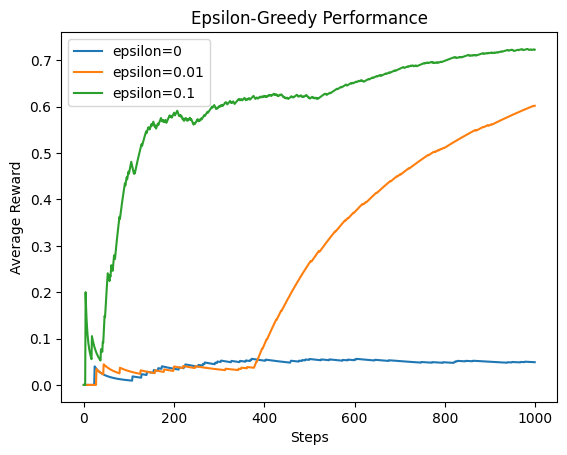

In [7]:
plt.plot(avg_0, label="epsilon=0")
plt.plot(avg_001, label="epsilon=0.01")
plt.plot(avg_01, label="epsilon=0.1")

plt.title("Epsilon-Greedy Performance")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.show()

At the beginning:
- Higher epsilon performs better because it explores more

In the long run:
- Small epsilon performs best because it balances exploration and exploitation

Epsilon = 0:
- Can get stuck in a bad arm

Epsilon = 0.1:
- Learns faster initially but may explore too much

A small epsilon (like 0.01) is often optimal